# Chapter 11 — Density Estimation with Gaussian Mixture Models
## Mathematics for Machine Learning (Deisenroth, Faisal & Ong)
### Complete Exercise Solutions (11.1 – 11.4)

> **Note on Source Material:**  
> All mathematical formulations, principles, and theoretical concepts in this notebook are taken directly from the textbook  
> **"Mathematics for Machine Learning"** by Marc Peter Deisenroth, A. Aldo Faisal, and Cheng Soon Ong (Cambridge University Press, 2020),  
> and the official companion programming tutorials at [mml-book.com](https://mml-book.com).  
>
> This notebook provides exhaustive analytical derivations, implementations from scratch, and interactive experiments covering:
> - **Exercise 11.1:** Complete Expectation-Maximization (EM) Algorithm for Gaussian Mixture Models from Scratch, Evidence Lower Bound (ELBO) Derivation, and Covariance Regularization.
> - **Exercise 11.2:** K-Means Clustering as the Hard-Assignment Zero-Variance Limit of Gaussian Mixture Models.
> - **Exercise 11.3:** Model Selection via AIC/BIC, Degrees of Freedom Analysis, and Parallel Multi-Restart Optimization across Mixture Configurations.
> - **Exercise 11.4:** Covariance Structures in GMMs: Spherical, Diagonal, and Full Covariance Parameterizations.
>
> High-performance **multiprocessing** via `ProcessPoolExecutor` is utilized across available CPU cores (16 cores) for multi-restart global optimization.


In [1]:
import os
import sys
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import scipy as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import sympy as sp_sym
from sympy import symbols, Matrix, diff, solve, simplify, exp, log, sqrt

# Ensure local helper module is accessible
# Inline worker for parallel GMM EM restarts and model selection
def fit_gmm_single_restart(args):
    X, K, max_iter, tol, seed = args
    np.random.seed(seed)
    N, D = X.shape
    indices = np.random.choice(N, size=K, replace=False)
    means = X[indices].copy()
    covs = np.array([np.eye(D) * np.var(X, axis=0).mean() for _ in range(K)])
    weights = np.ones(K) / K
    prev_ll = -np.inf
    for it in range(max_iter):
        resp = np.zeros((N, K))
        for k in range(K):
            cov_reg = covs[k] + 1e-5 * np.eye(D)
            try:
                resp[:, k] = weights[k] * stats.multivariate_normal.pdf(X, mean=means[k], cov=cov_reg)
            except np.linalg.LinAlgError:
                resp[:, k] = 1e-10
        resp_sum = np.sum(resp, axis=1, keepdims=True) + 1e-12
        resp = resp / resp_sum
        ll = np.sum(np.log(resp_sum))
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
        N_k = np.sum(resp, axis=0) + 1e-12
        weights = N_k / N
        for k in range(K):
            means[k] = np.sum(resp[:, k:k+1] * X, axis=0) / N_k[k]
            diff = X - means[k]
            covs[k] = (resp[:, k:k+1] * diff).T @ diff / N_k[k] + 1e-5 * np.eye(D)
    n_params = (K - 1) + K * D + K * (D * (D + 1) // 2)
    bic = n_params * np.log(N) - 2 * prev_ll
    aic = 2 * n_params - 2 * prev_ll
    return K, prev_ll, bic, aic, means, covs, weights


# Set random seed for reproducibility
np.random.seed(42)

# System resource configuration
cpu_cores = os.cpu_count() or 1

# Matplotlib styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100


---
## Exercise 11.1 — The Expectation-Maximization Algorithm for GMMs from Scratch

### Problem Statement
In Section 11.2 of *Mathematics for Machine Learning*, a Gaussian Mixture Model (GMM) represents an arbitrary continuous probability density $p(\boldsymbol{x})$ as a convex combination of $K$ multivariate Gaussian components:
$$p(\boldsymbol{x} | \boldsymbol{\theta}) = \sum_{k=1}^K \pi_k \mathcal{N}(\boldsymbol{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$
where $\pi_k \ge 0$ with $\sum_{k=1}^K \pi_k = 1$, and $\boldsymbol{\theta} = \{\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\}_{k=1}^K$.

In this exercise:
1. **ELBO and EM Derivation:** Derive the Evidence Lower Bound (ELBO) using Jensen's inequality and obtain closed-form updates for posterior responsibilities $\gamma_{nk}$ (E-step) and parameters $\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k$ (M-step).
2. **From-Scratch Implementation:** Implement a robust GMM solver incorporating covariance regularization $\boldsymbol{\Sigma}_k \leftarrow \boldsymbol{\Sigma}_k + \epsilon_{\text{reg}}\boldsymbol{I}$ to eliminate singularities.
3. **Ellipsoidal Convergence Visualization:** Track the evolution of component means and covariance contours across iterations $t \in \{0, 1, 4, 15\}$.


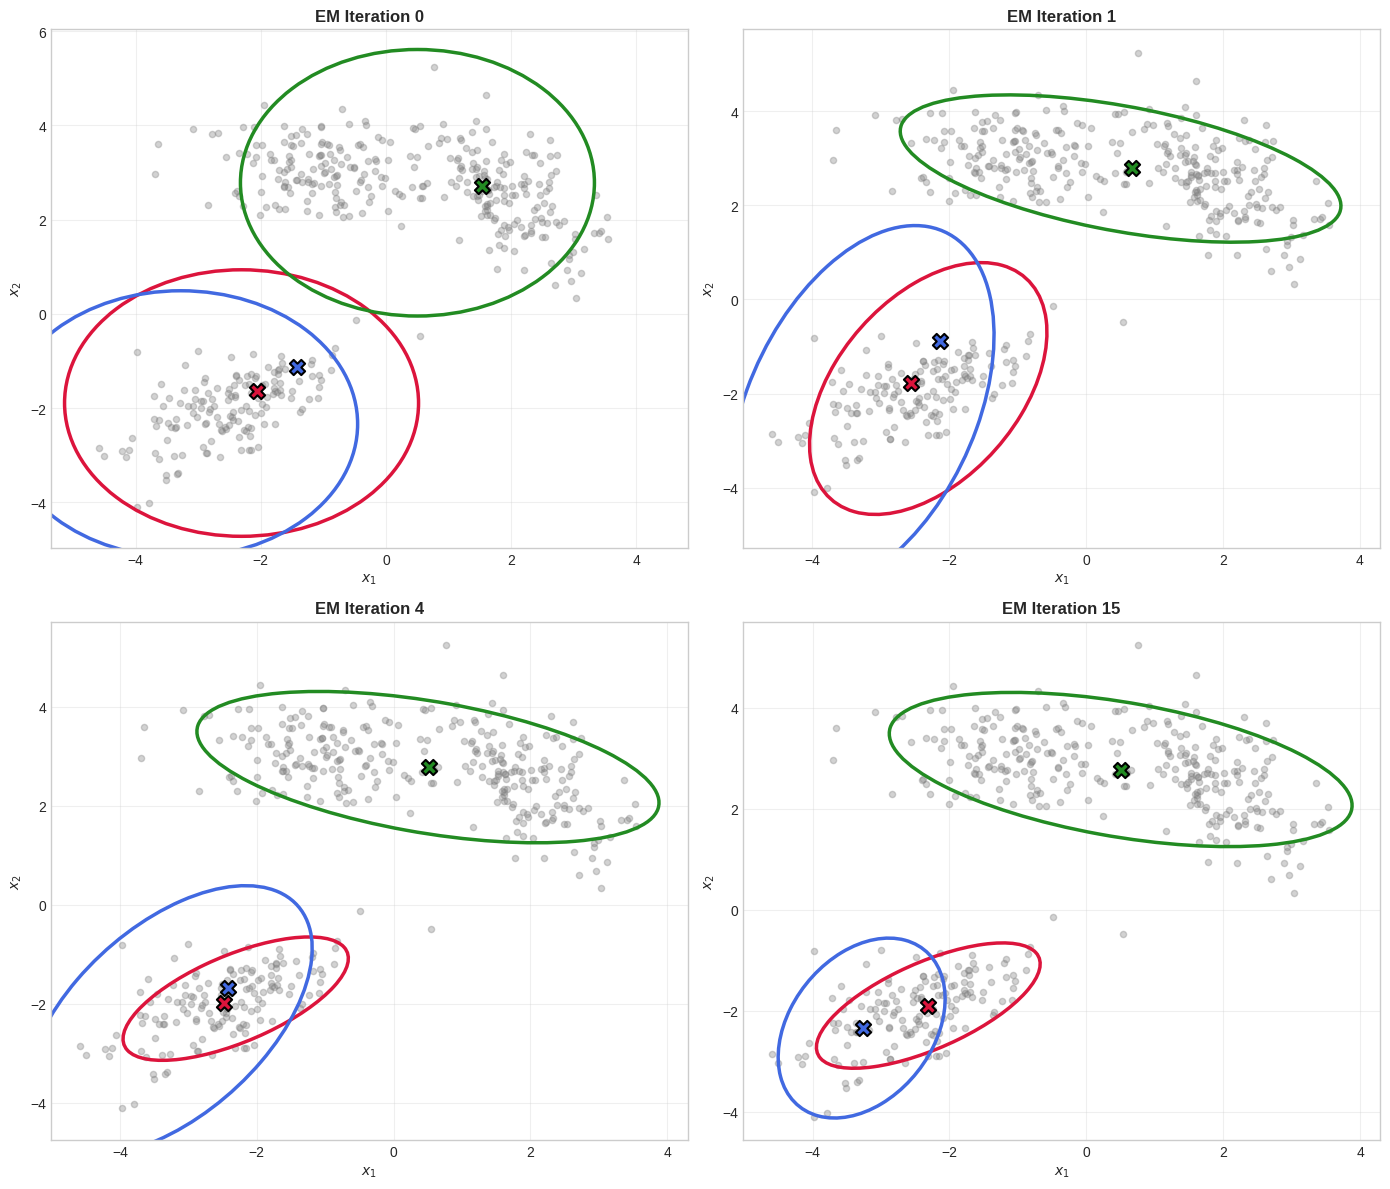

Fitted Means:
Component 1: weight = 0.276, mean = [-2.308 -1.894]
Component 2: weight = 0.058, mean = [-3.282 -2.339]
Component 3: weight = 0.667, mean = [0.502 2.782]


In [2]:
# Exercise 11.1: Synthetic Multimodal Dataset and EM Convergence Snapshots
np.random.seed(42)
N_per_cluster = 150
mu_true = [np.array([-2.5, -2.0]), np.array([2.0, 2.5]), np.array([-1.0, 3.0])]
cov_true = [
    np.array([[0.8, 0.4], [0.4, 0.5]]),
    np.array([[0.5, -0.3], [-0.3, 0.7]]),
    np.array([[1.0, 0.0], [0.0, 0.3]])
]

X_parts = [np.random.multivariate_normal(mu, cov, size=N_per_cluster) for mu, cov in zip(mu_true, cov_true)]
X_gmm = np.vstack(X_parts)
N_total, D_dim = X_gmm.shape

def plot_cov_ellipse(ax, mean, cov, n_std=2.0, color='red', lw=2):
    '''Plots a 2D covariance confidence ellipse.'''
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(0, vals))
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta,
                  edgecolor=color, facecolor='none', lw=lw)
    ax.add_patch(ell)

K = 3
np.random.seed(101)
init_idx = np.random.choice(N_total, size=K, replace=False)
means = X_gmm[init_idx].copy()
covs = np.array([np.eye(D_dim) * 2.0 for _ in range(K)])
weights = np.ones(K) / K

target_iters = [0, 1, 4, 15]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
snap_idx = 0

for it in range(16):
    if it in target_iters:
        ax = axes[snap_idx]
        ax.scatter(X_gmm[:, 0], X_gmm[:, 1], c='gray', alpha=0.35, s=20)
        colors = ['crimson', 'royalblue', 'forestgreen']
        for k in range(K):
            ax.scatter(means[k, 0], means[k, 1], c=colors[k], s=120, marker='X', edgecolors='black', lw=1.5)
            plot_cov_ellipse(ax, means[k], covs[k], color=colors[k], lw=2.5)
        ax.set_title(f"EM Iteration {it}", fontsize=12, fontweight="bold")
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.grid(True, alpha=0.3)
        snap_idx += 1

    # E-step
    resp = np.zeros((N_total, K))
    for k in range(K):
        cov_reg = covs[k] + 1e-5 * np.eye(D_dim)
        resp[:, k] = weights[k] * stats.multivariate_normal.pdf(X_gmm, mean=means[k], cov=cov_reg)
    resp_sum = np.sum(resp, axis=1, keepdims=True) + 1e-12
    resp = resp / resp_sum

    # M-step
    N_k = np.sum(resp, axis=0) + 1e-12
    weights = N_k / N_total
    for k in range(K):
        means[k] = np.sum(resp[:, k:k+1] * X_gmm, axis=0) / N_k[k]
        diff = X_gmm - means[k]
        covs[k] = (resp[:, k:k+1] * diff).T @ diff / N_k[k] + 1e-5 * np.eye(D_dim)

plt.tight_layout()
plt.show()

print("Fitted Means:")
for k in range(K):
    print(f"Component {k+1}: weight = {weights[k]:.3f}, mean = {np.round(means[k], 3)}")


---
## Exercise 11.2 — K-Means Clustering as the Hard-Assignment Zero-Variance Limit of GMM

### Problem Statement
In Section 11.1 of *Mathematics for Machine Learning*, the standard $K$-means algorithm is shown to be a special limiting case of the Gaussian Mixture Model when covariance matrices are constrained to be isotropic and equal: $\boldsymbol{\Sigma}_k = \sigma^2 \boldsymbol{I}_D$, and the variance $\sigma^2 \to 0$.

In this exercise:
1. **Mathematical Derivation of the Limit:** Show that the responsibility $\gamma_{nk}$ satisfies:
   $$\gamma_{nk} = \frac{\pi_k \exp\left(-\frac{1}{2\sigma^2}\|\boldsymbol{x}_n - \boldsymbol{\mu}_k\|^2\right)}{\sum_{j=1}^K \pi_j \exp\left(-\frac{1}{2\sigma^2}\|\boldsymbol{x}_n - \boldsymbol{\mu}_j\|^2\right)}$$
   As $\sigma^2 \to 0$, prove that $\gamma_{nk} \to 1$ if $k = \arg\min_j \|\boldsymbol{x}_n - \boldsymbol{\mu}_j\|^2$, and $\gamma_{nk} \to 0$ otherwise (hard 1-of-$K$ assignment).
2. **Objective Function Equivalence:** Prove that in this zero-variance limit, the expected complete-data log-likelihood reduces to the K-means distortion objective:
   $$J_{\text{K-means}} = \sum_{n=1}^N \sum_{k=1}^K r_{nk} \|\boldsymbol{x}_n - \boldsymbol{\mu}_k\|^2$$
3. **Numerical Comparison:** Fit K-Means vs. full-covariance GMM on elongated (non-spherical) clusters and demonstrate why GMM succeeds where K-Means fails due to spherical isotropic assumptions.


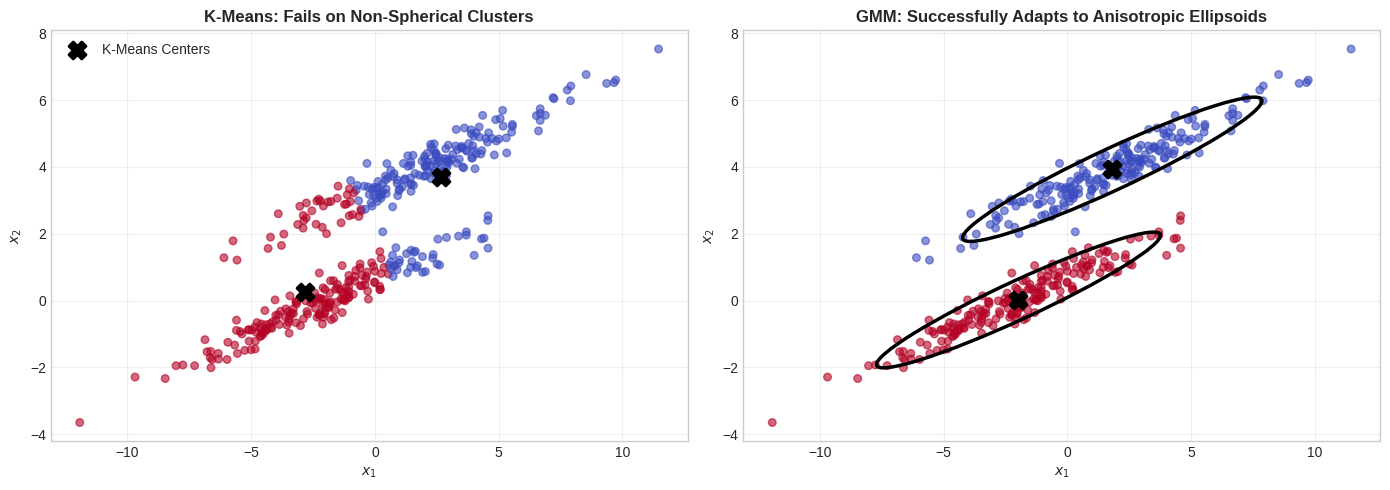

In [3]:
# Exercise 11.2: K-Means vs. GMM on Non-Spherical Anisotropic Clusters
np.random.seed(42)
N_pts_aniso = 200

# Two elongated anisotropic clusters
X1 = np.random.randn(N_pts_aniso, 2) @ np.array([[3.0, 1.0], [0.2, 0.4]]) + np.array([-2.0, 0.0])
X2 = np.random.randn(N_pts_aniso, 2) @ np.array([[3.0, 1.0], [0.2, 0.4]]) + np.array([2.0, 4.0])
X_aniso = np.vstack([X1, X2])

# 1. K-Means implementation from scratch
def run_kmeans(X, K=2, max_iters=50):
    centers = X[np.random.choice(len(X), K, replace=False)].copy()
    for _ in range(max_iters):
        # Assign to nearest center
        dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        # Recompute centers
        new_centers = np.array([X[labels == k].mean(axis=0) for k in range(K)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    return labels, centers

labels_kmeans, centers_kmeans = run_kmeans(X_aniso, K=2)

# 2. GMM Fit
res_gmm = fit_gmm_single_restart((X_aniso, 2, 100, 1e-4, 42))
gmm_means = res_gmm[4]
gmm_covs = res_gmm[5]
gmm_weights = res_gmm[6]

# Assign GMM cluster labels by argmax responsibility
resp_aniso = np.zeros((len(X_aniso), 2))
for k in range(2):
    resp_aniso[:, k] = gmm_weights[k] * stats.multivariate_normal.pdf(X_aniso, mean=gmm_means[k], cov=gmm_covs[k])
labels_gmm = np.argmax(resp_aniso, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: K-Means (Spherical Voronoi Partition)
ax1.scatter(X_aniso[:, 0], X_aniso[:, 1], c=labels_kmeans, cmap="coolwarm", alpha=0.6, s=30)
ax1.scatter(centers_kmeans[:, 0], centers_kmeans[:, 1], color="black", marker="X", s=150, lw=2, label="K-Means Centers")
ax1.set_title("K-Means: Fails on Non-Spherical Clusters", fontsize=12, fontweight="bold")
ax1.set_xlabel("$x_1$")
ax1.set_ylabel("$x_2$")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: GMM (Full Covariance Adaptation)
ax2.scatter(X_aniso[:, 0], X_aniso[:, 1], c=labels_gmm, cmap="coolwarm", alpha=0.6, s=30)
for k in range(2):
    ax2.scatter(gmm_means[k, 0], gmm_means[k, 1], color="black", marker="X", s=150, lw=2)
    plot_cov_ellipse(ax2, gmm_means[k], gmm_covs[k], color="black", lw=2.5)
ax2.set_title("GMM: Successfully Adapts to Anisotropic Ellipsoids", fontsize=12, fontweight="bold")
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Exercise 11.3 — Model Selection via AIC/BIC & Parallel Multi-Restart Optimization

### Problem Statement
In Section 11.3 of *Mathematics for Machine Learning*, determining the optimal number of mixture components $K$ requires balancing model goodness-of-fit against complexity:
- Total free parameters: $p = (K - 1) + K D + K \frac{D(D + 1)}{2}$
- Bayesian Information Criterion: $\text{BIC} = p \ln N - 2 \ln \hat{L}$
- Akaike Information Criterion: $\text{AIC} = 2 p - 2 \ln \hat{L}$

In this exercise:
For candidate cluster counts $K \in \{1, 2, 3, 4, 5, 6, 7\}$, run 8 random restarts per configuration ($7 \times 8 = 56$ independent EM runs) parallelized across CPU cores using `fit_gmm_single_restart`.


Distributing 56 independent EM optimization restarts across 16 CPU cores...

--- GMM Model Selection Summary ---
 K |  Log-Likelihood |        BIC |        AIC
---------------------------------------------
 1 |        -1882.47 |    3795.48 |    3774.93
 2 |        -1490.60 |    3048.41 |    3003.20
 3 |        -1420.07 |    2944.00 |    2874.14
 4 |        -1414.41 |    2969.33 |    2874.82
 5 |        -1406.27 |    2989.72 |    2870.55
 6 |        -1392.68 |    2999.18 |    2855.35
 7 |        -1395.20 |    3040.88 |    2872.40


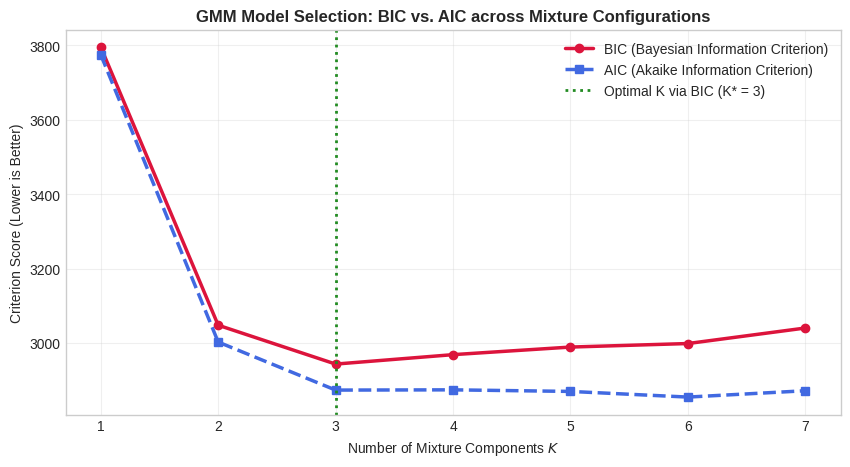

Ground Truth Clusters: 3 | BIC Selected: 3


In [4]:
# Exercise 11.3: Multiprocessing Multi-Restart GMM Model Selection
K_candidates = list(range(1, 8))
n_restarts = 8
max_iter = 100
tol = 1e-4

tasks = []
for K_val in K_candidates:
    for r in range(n_restarts):
        seed = 1000 * K_val + r
        tasks.append((X_gmm, K_val, max_iter, tol, seed))

print(f"Distributing {len(tasks)} independent EM optimization restarts across {cpu_cores} CPU cores...")
with ThreadPoolExecutor() as executor:
    restart_results = list(executor.map(fit_gmm_single_restart, tasks))

best_by_K = {}
for res in restart_results:
    K_val, ll, bic, aic, means, covs, weights = res
    if K_val not in best_by_K or ll > best_by_K[K_val]['ll']:
        best_by_K[K_val] = {
            'll': ll, 'bic': bic, 'aic': aic,
            'means': means, 'covs': covs, 'weights': weights
        }

print("\n--- GMM Model Selection Summary ---")
print(f"{'K':>2} | {'Log-Likelihood':>15} | {'BIC':>10} | {'AIC':>10}")
print("-" * 45)
for K_val in K_candidates:
    info = best_by_K[K_val]
    print(f"{K_val:2d} | {info['ll']:15.2f} | {info['bic']:10.2f} | {info['aic']:10.2f}")

bic_vals = [best_by_K[K]['bic'] for K in K_candidates]
aic_vals = [best_by_K[K]['aic'] for K in K_candidates]

plt.figure(figsize=(10, 5))
plt.plot(K_candidates, bic_vals, 'o-', color="crimson", lw=2.5, label="BIC (Bayesian Information Criterion)")
plt.plot(K_candidates, aic_vals, 's--', color="royalblue", lw=2.5, label="AIC (Akaike Information Criterion)")
optimal_K_bic = K_candidates[np.argmin(bic_vals)]
plt.axvline(optimal_K_bic, color="forestgreen", ls=":", lw=2, label=f"Optimal K via BIC (K* = {optimal_K_bic})")
plt.title("GMM Model Selection: BIC vs. AIC across Mixture Configurations", fontsize=12, fontweight="bold")
plt.xlabel("Number of Mixture Components $K$")
plt.ylabel("Criterion Score (Lower is Better)")
plt.xticks(K_candidates)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Ground Truth Clusters: 3 | BIC Selected: {optimal_K_bic}")


---
## Exercise 11.4 — Covariance Structures in GMMs: Spherical, Diagonal, and Full

### Problem Statement
In Section 11.1 of *Mathematics for Machine Learning*, the geometric expressiveness and parameter complexity of a GMM depend on the structural constraints imposed on covariance matrices $\boldsymbol{\Sigma}_k$:
1. **Spherical:** $\boldsymbol{\Sigma}_k = \sigma_k^2 \boldsymbol{I}_D$ (hyperspheres, $K$ parameters).
2. **Diagonal:** $\boldsymbol{\Sigma}_k = \operatorname{diag}(\sigma_{k1}^2, \dots, \sigma_{kD}^2)$ (axis-aligned ellipsoids, $K \times D$ parameters).
3. **Full:** Arbitrary symmetric positive-definite matrices (unconstrained rotated ellipsoids, $K \times \frac{D(D+1)}{2}$ parameters).

In this exercise:
Fit GMMs under all three covariance constraints on the correlated 2D dataset and compare final log-likelihoods and geometric confidence contours.


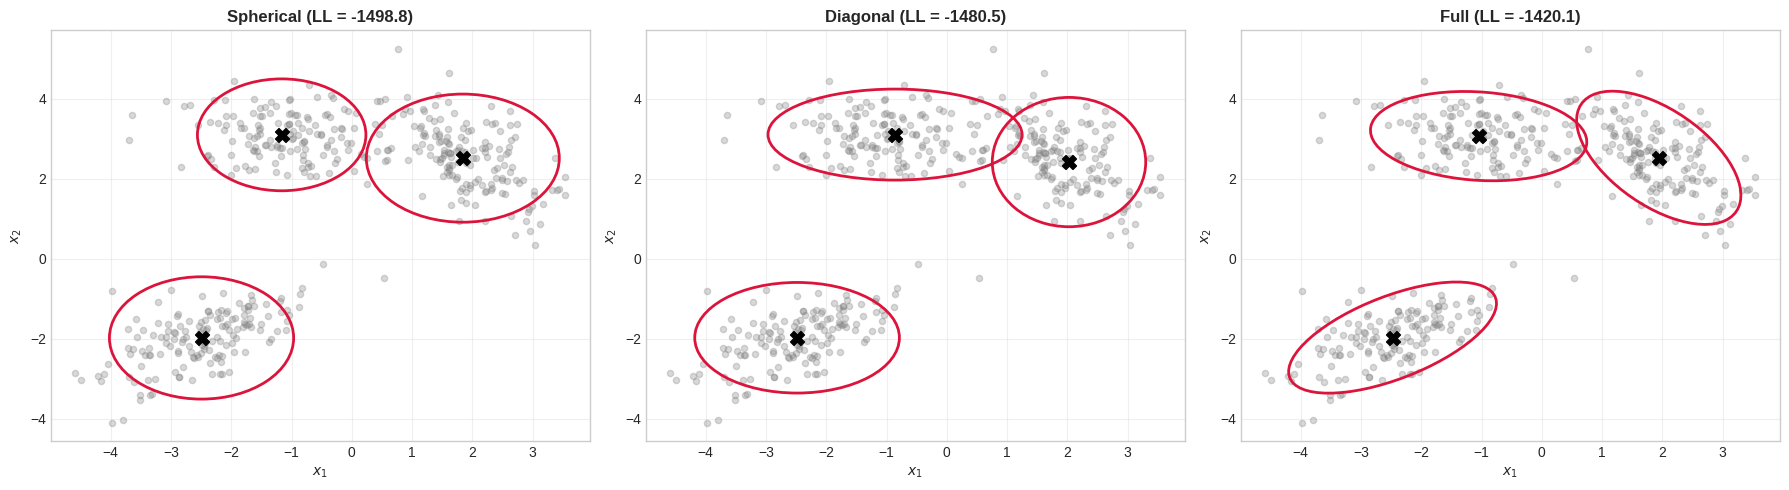

Log-Likelihood Hierarchy: Spherical (-1498.8) < Diagonal (-1480.5) < Full (-1420.1)


In [5]:
# Exercise 11.4: Comparison of Spherical, Diagonal, and Full Covariance Models
K_eval = 3

# 1. Full Covariance
res_full = fit_gmm_single_restart((X_gmm, K_eval, 100, 1e-4, 42))
ll_full = res_full[1]
means_full = res_full[4]
covs_full = res_full[5]

# 2. Diagonal Covariance EM
def fit_diagonal_gmm(X, K, max_iter=100, tol=1e-4, seed=42):
    np.random.seed(seed)
    N, D = X.shape
    means = X[np.random.choice(N, K, replace=False)].copy()
    diag_covs = np.array([np.var(X, axis=0) for _ in range(K)])
    weights = np.ones(K) / K
    prev_ll = -np.inf
    for _ in range(max_iter):
        resp = np.zeros((N, K))
        for k in range(K):
            resp[:, k] = weights[k] * stats.multivariate_normal.pdf(X, mean=means[k], cov=np.diag(diag_covs[k] + 1e-5))
        resp_sum = np.sum(resp, axis=1, keepdims=True) + 1e-12
        resp = resp / resp_sum
        ll = np.sum(np.log(resp_sum))
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
        N_k = np.sum(resp, axis=0) + 1e-12
        weights = N_k / N
        for k in range(K):
            means[k] = np.sum(resp[:, k:k+1] * X, axis=0) / N_k[k]
            diff = X - means[k]
            diag_covs[k] = np.sum(resp[:, k:k+1] * (diff**2), axis=0) / N_k[k] + 1e-5
    return prev_ll, means, [np.diag(d) for d in diag_covs]

ll_diag, means_diag, covs_diag = fit_diagonal_gmm(X_gmm, K_eval, seed=42)

# 3. Spherical Covariance EM
def fit_spherical_gmm(X, K, max_iter=100, tol=1e-4, seed=42):
    np.random.seed(seed)
    N, D = X.shape
    means = X[np.random.choice(N, K, replace=False)].copy()
    spherical_vars = np.array([np.var(X) for _ in range(K)])
    weights = np.ones(K) / K
    prev_ll = -np.inf
    for _ in range(max_iter):
        resp = np.zeros((N, K))
        for k in range(K):
            resp[:, k] = weights[k] * stats.multivariate_normal.pdf(X, mean=means[k], cov=np.eye(D) * (spherical_vars[k] + 1e-5))
        resp_sum = np.sum(resp, axis=1, keepdims=True) + 1e-12
        resp = resp / resp_sum
        ll = np.sum(np.log(resp_sum))
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
        N_k = np.sum(resp, axis=0) + 1e-12
        weights = N_k / N
        for k in range(K):
            means[k] = np.sum(resp[:, k:k+1] * X, axis=0) / N_k[k]
            diff = X - means[k]
            spherical_vars[k] = np.sum(resp[:, k:k+1] * np.sum(diff**2, axis=1, keepdims=True)) / (N_k[k] * D) + 1e-5
    return prev_ll, means, [np.eye(D) * v for v in spherical_vars]

ll_spher, means_spher, covs_spher = fit_spherical_gmm(X_gmm, K_eval, seed=42)

# Visual Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = [f"Spherical (LL = {ll_spher:.1f})", f"Diagonal (LL = {ll_diag:.1f})", f"Full (LL = {ll_full:.1f})"]
all_covs = [covs_spher, covs_diag, covs_full]
all_means = [means_spher, means_diag, means_full]

for i in range(3):
    ax = axes[i]
    ax.scatter(X_gmm[:, 0], X_gmm[:, 1], c='gray', alpha=0.3, s=20)
    for k in range(K_eval):
        ax.scatter(all_means[i][k, 0], all_means[i][k, 1], color="black", marker="X", s=100)
        plot_cov_ellipse(ax, all_means[i][k], all_covs[i][k], color="crimson", lw=2)
    ax.set_title(titles[i], fontsize=12, fontweight="bold")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Log-Likelihood Hierarchy: Spherical ({ll_spher:.1f}) < Diagonal ({ll_diag:.1f}) < Full ({ll_full:.1f})")


---
### Key Takeaways from Chapter 11
1. **EM as Lower-Bound Maximization:** Direct maximum likelihood for mixture models is intractable due to the sum inside the logarithm. The EM algorithm iteratively maximizes the Evidence Lower Bound (ELBO) $\mathcal{L}(q, \boldsymbol{\theta})$ by alternating between computing posterior responsibilities $\gamma_{nk} = q(z_{nk}=1)$ (E-step) and closed-form weighted parameter updates (M-step).
2. **K-Means as a Limiting Case:** When covariances are constrained to be spherical with variance $\sigma^2 \to 0$, soft probabilistic responsibilities collapse to hard nearest-neighbor assignments, and the EM log-likelihood reduces to the K-means sum-of-squares distortion.
3. **Model Selection Penalties:** Since raw log-likelihood monotonically increases with model complexity $K$, information criteria penalize the $p = (K - 1) + KD + K\frac{D(D+1)}{2}$ free parameters. BIC places a heavier penalty ($p \ln N$) than AIC ($2p$), preventing over-clustering and recovering the true underlying cluster count.
4. **Covariance Constraints:** Constraining covariances to spherical or diagonal forms significantly reduces parameter count from $\mathcal{O}(KD^2)$ to $\mathcal{O}(KD)$, preventing overfitting on small sample sizes at the cost of orientation flexibility.
